Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare

Loading Datasets


In [2]:
# Load SEDA dataset
df = pd.read_csv("seda2023_cov_state_annual.csv")

# Quick look
df.head()

,sedafips,year,enrl38,totenrl,perfrl,perblk,perhsp,perasn,pernam,peroth,perwht
0,1,2016,333794.06,743100.19,0.571,0.332,0.068,0.015,0.009,0.020,0.556
1,1,2017,337799.00,744817.31,0.578,0.330,0.074,0.015,0.009,0.022,0.549
2,1,2018,340453.00,742606.88,0.569,0.328,0.079,0.016,0.009,0.022,0.545
3,1,2019,339357.00,739726.00,0.560,0.325,0.084,0.016,0.009,0.024,0.542
4,1,2022,336749.00,747115.00,0.507,0.320,0.100,0.016,0.009,0.029,0.526


Data Exploration


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nSummary Statistics:\n")
print(df.describe())

print("\nMissing values:\n")
print(df.isnull().sum())

Shape of dataset: (255, 11)

Columns:
 Index(['sedafips', 'year', 'enrl38', 'totenrl', 'perfrl', 'perblk', 'perhsp',
       'perasn', 'pernam', 'peroth', 'perwht'],
      dtype='object')

Summary Statistics:

         sedafips         year        enrl38       totenrl      perfrl  \
count  255.000000   255.000000  2.550000e+02  2.550000e+02  255.000000   
mean    28.960784  2018.400000  4.428866e+05  9.819426e+05    0.486322   
std     15.707665     2.063175  5.233444e+05  1.159306e+06    0.109665   
min      1.000000  2016.000000  3.092600e+04  8.038800e+04    0.210000   
25%     16.000000  2017.000000  1.206705e+05  2.757393e+05    0.409000   
50%     29.000000  2018.000000  3.083150e+05  6.939668e+05    0.475000   
75%     42.000000  2019.000000  5.128452e+05  1.116868e+06    0.560000   
max     56.000000  2022.000000  2.840360e+06  6.215773e+06    0.984000   

           perblk      perhsp      perasn      pernam      peroth      perwht  
count  255.000000  255.000000  255.000000  2

Mean Enrollment by Year

In [4]:
year_means = df.groupby("year")["totenrl"].mean()

print(year_means)

year
2016    983950.425098
2017    986778.142745
2018    988080.222745
2019    988197.491569
2022    962706.882353
Name: totenrl, dtype: float64


Enrollment Trend

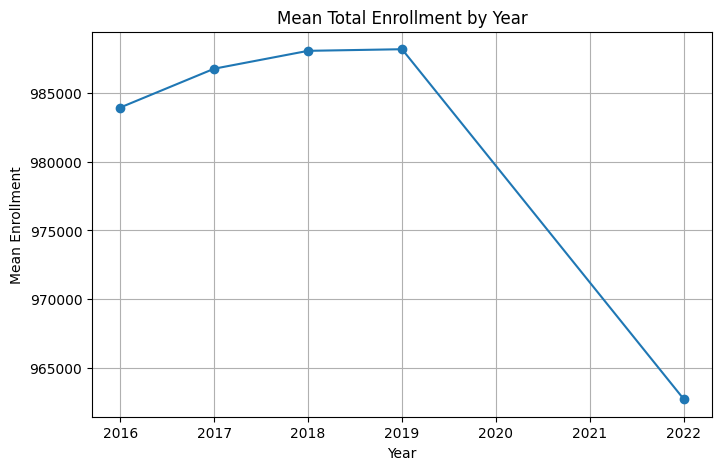

In [5]:
plt.figure(figsize=(8,5))
plt.plot(year_means.index, year_means.values, marker='o')

plt.title("Mean Total Enrollment by Year")
plt.xlabel("Year")
plt.ylabel("Mean Enrollment")

plt.grid()
plt.show()

Boxplot

/tmp/ipykernel_3514/1341259438.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years)


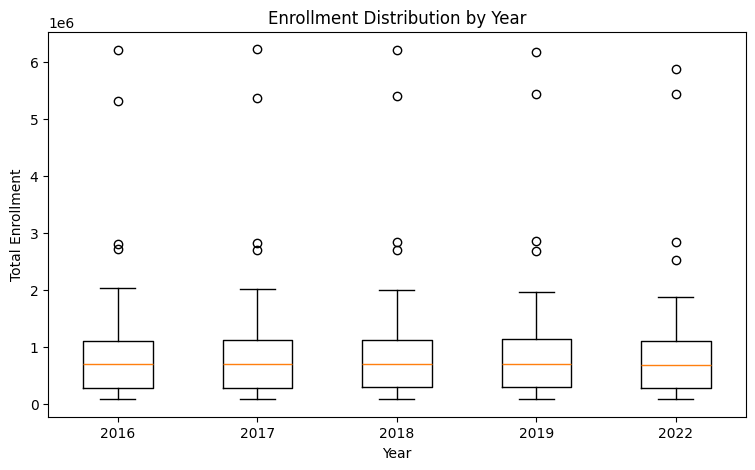

In [6]:
years = sorted(df["year"].unique())

data = [df[df["year"] == y]["totenrl"] for y in years]

plt.figure(figsize=(9,5))
plt.boxplot(data, labels=years)

plt.title("Enrollment Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Total Enrollment")

plt.show()

Preparation for Hypothesis Testing

In [7]:
# Convert to wide format
wide = df.pivot(index="sedafips", columns="year", values="totenrl")

# Drop missing values
wide = wide.dropna()

print(wide.head())

year            2016        2017        2018        2019       2022
sedafips                                                           
1          743100.19   744817.31   742606.88   739726.00   747115.0
2          132665.30   132936.59   133059.50   130967.20   129941.0
4         1111900.25  1121836.75  1108709.25  1140920.75  1131888.0
5          492132.00   493447.00   496085.00   495340.81   489565.0
6         6210853.50  6215773.00  6207749.50  6173963.00  5871451.0


Changes from 2019-2022

In [8]:
change = wide[2022] - wide[2019]

print("Mean change:", change.mean())

Mean change: -25490.609215686272


Histogram of Change

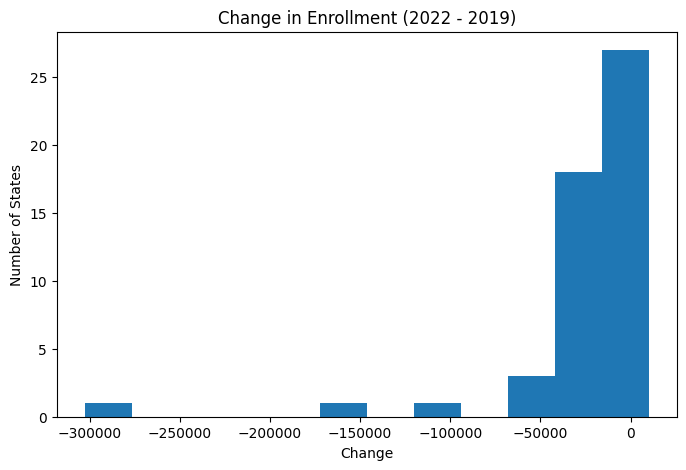

In [9]:
plt.figure(figsize=(8,5))
plt.hist(change, bins=12)

plt.title("Change in Enrollment (2022 - 2019)")
plt.xlabel("Change")
plt.ylabel("Number of States")

plt.show()

Paired T-test
Hypotheses:
H₀: No change in enrollment (2019 = 2022)
H₁: Enrollment changed

In [10]:
t_stat, p_val = ttest_rel(wide[2019], wide[2022])

print("Paired t-test:")
print("t-stat =", t_stat)
print("p-value =", p_val)

Paired t-test:
t-stat = 3.786892988769984
p-value = 0.00041010981254025294


The paired t-test shows a statistically significant decline in student enrollment
from 2019 to 2022 (p < 0.05), suggesting that COVID-19 had a measurable impact
on student participation in education.

Wilcoxon Test

In [11]:
w_stat, p_val_w = wilcoxon(wide[2019], wide[2022])

print("Wilcoxon test:")
print("stat =", w_stat)
print("p-value =", p_val_w)

Wilcoxon test:
stat = 89.0
p-value = 7.43329089377485e-08


Friedman Test (All Years)

In [12]:
fried_stat, fried_p = friedmanchisquare(
    wide[2016],
    wide[2017],
    wide[2018],
    wide[2019],
    wide[2022]
)

print("Friedman test:")
print("stat =", fried_stat)
print("p-value =", fried_p)

Friedman test:
stat = 23.325490196078363
p-value = 0.00010900891692395366


In [14]:
df.corr(numeric_only=True)

,sedafips,year,enrl38,totenrl,perfrl,perblk,perhsp,perasn,pernam,peroth,perwht
sedafips,1.000000e+00,-1.855230e-13,-0.062340,-0.058891,-0.255476,-0.241881,-0.145585,-0.148624,-0.036541,-0.068688,0.357035
year,-1.855230e-13,1.000000e+00,-0.009216,-0.006677,-0.118233,-0.010753,0.061140,0.004748,-0.015191,0.215262,-0.061734
enrl38,-6.233989e-02,-9.216112e-03,1.000000,0.999818,0.251495,0.052974,0.551822,0.073622,-0.227636,-0.109364,-0.399599
totenrl,-5.889094e-02,-6.677034e-03,0.999818,1.000000,0.249475,0.052840,0.551338,0.073694,-0.227914,-0.110397,-0.398996
perfrl,-2.554761e-01,-1.182331e-01,0.251495,0.249475,1.000000,0.617303,0.239739,-0.056343,-0.034474,-0.075213,-0.579405
perblk,-2.418808e-01,-1.075287e-02,0.052974,0.052840,0.617303,1.000000,-0.146152,-0.155042,-0.305980,-0.254501,-0.456975
perhsp,-1.455849e-01,6.114027e-02,0.551822,0.551338,0.239739,-0.146152,1.000000,0.103481,-0.024597,-0.050025,-0.641318
perasn,-1.486242e-01,4.747724e-03,0.073622,0.073694,-0.056343,-0.155042,0.103481,1.000000,-0.063549,0.664807,-0.437171
pernam,-3.654104e-02,-1.519063e-02,-0.227636,-0.227914,-0.034474,-0.305980,-0.024597,-0.063549,1.000000,0.344858,-0.000332
peroth,-6.868801e-02,2.152619e-01,-0.109364,-0.110397,-0.075213,-0.254501,-0.050025,0.664807,0.344858,1.000000,-0.251278
